In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [6]:
df=pd.read_csv(r"C:\Users\SATWIK\OneDrive\Desktop\MachineLearning\house price prediction\House Price Prediction Dataset.csv")
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [7]:
df.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


In [8]:
df.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [9]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Location'].unique()

array(['Downtown', 'Suburban', 'Urban', 'Rural'], dtype=object)

In [15]:
df['Condition'].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [16]:
df['Garage'].unique()

array(['No', 'Yes'], dtype=object)

In [17]:
l=df['Location'].value_counts()

([<matplotlib.patches.Wedge at 0x2ae0c13a690>,
 [Text(0.7038255669251674, 0.8453576588299575, 'Downtown'),
  Text(-0.8909333533346369, 0.6451649090859635, 'Urban'),
  Text(-0.6891142954408993, -0.8573922601814138, 'Suburban'),
  Text(0.8089268355003273, -0.7454108765019644, 'Rural')],
 [Text(0.3839048546864549, 0.4611041775436131, '27.9%'),
  Text(-0.4859636472734382, 0.3519081322287073, '24.2%'),
  Text(-0.3758805247859451, -0.46766850555349837, '24.1%'),
  Text(0.4412328193638148, -0.40658775081925325, '23.7%')])

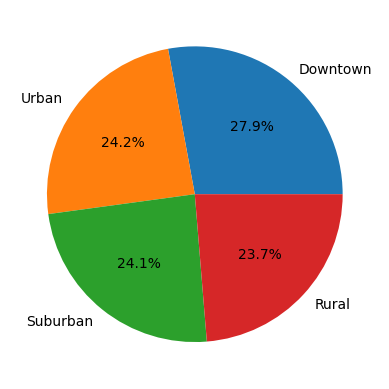

In [18]:
plt.pie(l.values,labels=l.index,autopct='%1.1f%%')

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
encoder = LabelEncoder()
df['Location']=encoder.fit_transform(df['Location'])
df['Condition']=encoder.fit_transform(df['Condition'])
df['Garage']=encoder.fit_transform(df['Garage'])

In [21]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,149919
1,2,4272,5,4,3,1958,0,0,0,424998
2,3,3592,2,2,3,1938,0,2,0,266746
3,4,966,4,2,2,1902,2,1,1,244020
4,5,4926,1,4,2,1975,0,1,1,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,2,3,0,295620
1996,1997,3046,5,2,1,2019,2,3,1,580929
1997,1998,1062,5,1,2,1903,1,3,0,476925
1998,1999,4062,3,1,2,1936,3,0,1,161119


In [23]:
x=df.drop(['Id','Price'],axis=1)
y=df['Price']

In [25]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
model=LinearRegression()

In [27]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
x_test

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
1860,633,1,4,2,1901,3,1,0
353,3856,1,1,2,1901,3,1,0
1333,1598,5,4,1,2013,3,0,0
905,1705,3,1,2,1996,0,2,1
1289,2564,5,2,3,1994,0,2,1
...,...,...,...,...,...,...,...,...
965,1811,1,3,3,1970,1,3,0
1284,794,3,2,2,2013,0,3,1
1739,3540,4,4,2,1939,0,3,1
261,3670,5,2,2,1910,0,2,1


In [29]:
y_test

1860    514764
353     694256
1333     66375
905     650243
1289    223285
         ...  
965     386940
1284    632570
1739    494049
261     562193
535     447530
Name: Price, Length: 400, dtype: int64

In [30]:
y_pred= model.predict(x_test)

In [31]:
y_pred

array([510844.55800609, 539418.87521843, 502542.9891788 , 560243.21537465,
       573676.09846645, 547450.38288388, 547911.36773467, 546992.57655005,
       562122.64093663, 568418.93231839, 543981.04201363, 568581.48917716,
       494180.93154274, 534369.80109663, 518672.2980485 , 533128.46015755,
       555154.11364786, 553804.89986875, 558980.34324236, 511668.88047104,
       539869.84134873, 530844.60400111, 527257.5665389 , 571513.68736262,
       555171.48683593, 532879.07240733, 515804.34515504, 517839.89088436,
       532023.74891802, 500256.21730707, 494862.38773326, 548059.5947312 ,
       542507.97281599, 570397.41193111, 524177.85942732, 488534.72921744,
       567201.35623307, 583701.76224155, 515786.43837086, 507811.07698988,
       499911.86352156, 521901.32428546, 521299.52562298, 538833.24606057,
       546811.39914863, 543351.32301536, 560351.23630284, 523613.18865934,
       551798.1481872 , 541335.07913986, 499705.44623932, 531759.01289588,
       561999.12398141, 5

In [32]:
y_pred=model.predict(x_test)

In [33]:
print(pd.Series(y_pred),y_test)

0      510844.558006
1      539418.875218
2      502542.989179
3      560243.215375
4      573676.098466
           ...      
395    551772.763549
396    549993.642575
397    520855.111982
398    540123.807488
399    569192.867687
Length: 400, dtype: float64 1860    514764
353     694256
1333     66375
905     650243
1289    223285
         ...  
965     386940
1284    632570
1739    494049
261     562193
535     447530
Name: Price, Length: 400, dtype: int64


In [34]:
mae=mean_absolute_error(y_test,y_pred)
mae

244419.99901363705

In [35]:
mse=mean_squared_error(y_test,y_pred)
mse


78729422262.6482

In [36]:
r2=r2_score(y_test,y_pred)
r2

-0.011961539273188215

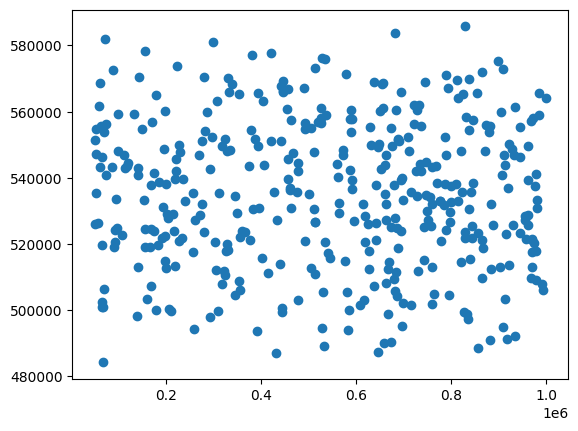

In [37]:
plt.scatter(y_test,y_pred)

In [38]:
new_house=[[1800,3,2,2,2018,2,1,1]]
predict_new_house_price=model.predict(new_house)
print(predict_new_house_price)


[550163.28332537]


C:\Users\SATWIK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
